# 1. Operators: arithmetic, comparisons and decisions

Learn to combine numbers, predict operation order, compare values, and compose Boolean conditions. Prerequisite: [Variables and data types](../../../01_Python_Foundations/01_variables_and_data_types.ipynb). You will calculate an error measure manually and use explicit checks to prevent division and shape mistakes. Allow two hours. Write the intermediate result of each expression before asking Python to evaluate it.

## 2. What problem does this solve?

An operator expresses a relationship or calculation between values. Small syntax differences can completely change an ML experiment: squaring a residual differs from doubling it, testing equality differs from assignment, and combining masks elementwise differs from asking whether an entire array is true.

Correct syntax alone does not guarantee correct mathematics. A program can run while calculating the wrong denominator, comparing incompatible units, or applying a condition in the wrong order. Understanding operators makes those failures inspectable.

## 3. Intuition and analogy

Think of a calculation as a sequence of instruction cards. Multiplication cards normally run before addition cards. Parentheses bundle a subtask that must finish first. Logical operators combine yes/no answers in the same way a checklist might require both a valid measurement and a known unit before accepting a record.

Use parentheses to communicate intent even when precedence would already give the desired answer. A reader should not need to remember every precedence rule to understand a scientific calculation.

## 4. Terminology

An **operand** is a value used by an operator. A **unary** operator acts on one operand, such as negation; a **binary** operator uses two. Arithmetic operators include `+`, `-`, `*`, `/`, `//`, `%`, and `**`. Comparison operators include `==`, `!=`, `<`, `<=`, `>`, and `>=`.

`and`, `or`, and `not` combine scalar conditions. **Precedence** controls which operation runs first. **Short-circuiting** means a logical expression can skip a later part once its result is already determined. An **augmented assignment**, such as `total += 1`, updates a name using its earlier value; mutable objects can have additional in-place behavior.

## 5. Mathematical foundations

Let residual $e_i=\hat y_i-y_i$ be prediction minus actual outcome for example i. Mean squared error is

$$\mathrm{MSE}=\frac{e_1^2+e_2^2+\cdots+e_n^2}{n}.$$

n is the number of evaluated examples. A square is multiplication by itself, written `e ** 2` in Python. If the outcome is measured in minutes, each squared residual and MSE has units of minutes squared. The sign disappears after squaring, so overprediction and underprediction contribute equally at the same magnitude.

The order matters: square each residual, add the squares, then divide by n. Squaring the mean residual is a different statistic and allows positive and negative errors to cancel before squaring.

## 6. Hand-calculated example

Predictions `[2,5]` and outcomes `[3,3]` produce residuals `[-1,2]`. Their squares are `[1,4]`; MSE is $(1+4)/2=2.5$. The mean residual is $(-1+2)/2=0.5$, whose square is 0.25. These two answers describe different things.

For integer batching, ten examples split into groups of at most four require three groups: four, four, and two. Integer quotient `10 // 4` gives two complete groups, and remainder `10 % 4` gives two leftover examples.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
predictions = [2, 5]
outcomes = [3, 3]
assert len(predictions) == len(outcomes) and len(outcomes) > 0
residuals = [prediction - actual for prediction, actual in zip(predictions, outcomes)]
squares = [error ** 2 for error in residuals]
mse = sum(squares) / len(squares)
squared_mean_error = (sum(residuals) / len(residuals)) ** 2
print('Residuals:', residuals, 'Squares:', squares)
print('MSE:', mse, 'Squared mean residual:', squared_mean_error)
assert mse == 2.5 and squared_mean_error == 0.25

Residuals: [-1, 2] Squares: [1, 4]
MSE: 2.5 Squared mean residual: 0.25


## 8. Step-by-step output inspection

In [3]:
print('Different grouping:', (2 + 3) * 4, 2 + 3 * 4)
print('Power and negation:', -3 ** 2, (-3) ** 2)
print('Division:', 10 / 4, 10 // 4, 10 % 4)
assert (2 + 3) * 4 == 20
assert 2 + 3 * 4 == 14
assert -3 ** 2 == -9 and (-3) ** 2 == 9
assert 10 == (10 // 4) * 4 + (10 % 4)

Different grouping: 20 14
Power and negation: -9 9
Division: 2.5 2 2


Exponentiation binds before unary minus in the first negative example, so `-3 ** 2` means `-(3 ** 2)`. Parentheses make the base negative in the second. Floor division rounds toward negative infinity: `-3 // 2` is -2, unlike truncating `int(-3/2)`, which gives -1.

## 9. Library implementation

NumPy applies numerical operators elementwise to compatible arrays. `np.mean` averages the resulting squared residuals. The scikit-learn metric independently implements the same evaluation definition, including validation of its input structure.

In [4]:
import numpy as np
from sklearn.metrics import mean_squared_error
errors = np.array(predictions) - np.array(outcomes)
numpy_mse = np.mean(errors ** 2)
assert numpy_mse == mse == mean_squared_error(outcomes, predictions)

Using a library reduces repetitive implementation work, but you still choose which arrays are predictions and outcomes, whether they are paired correctly, and whether the metric suits the task. MSE on arbitrary category codes is usually not an appropriate classification metric.

## 10. Visualization

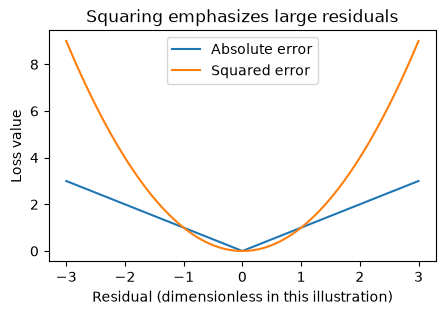

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
error_grid = np.linspace(-3, 3, 101)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(error_grid, np.abs(error_grid), label='Absolute error')
ax.plot(error_grid, error_grid ** 2, label='Squared error')
ax.set(xlabel='Residual (dimensionless in this illustration)', ylabel='Loss value', title='Squaring emphasizes large residuals')
ax.legend()
display(fig)
plt.close(fig)

Both curves are symmetric around zero. At residual magnitude three, absolute loss is three and squared loss is nine. The illustration uses dimensionless values; with measured targets, the two losses have different units and should not be interpreted as directly interchangeable quantities.

## 11. Realistic experiment: validating measurements

Suppose an invented sensor accepts temperatures from -20 through 50 Celsius. The following mask accepts only values inside both boundaries. Parenthesize each comparison before combining NumPy Boolean arrays with `&`.

In [6]:
temperatures = np.array([-25., -20., 0., 50., 55.])
valid = (temperatures >= -20) & (temperatures <= 50)
accepted = temperatures[valid]
np.testing.assert_array_equal(accepted, [-20, 0, 50])
print('Validity mask:', valid, 'Accepted:', accepted)
count = 0
safe_average = None if count == 0 else 10 / count
assert safe_average is None

Validity mask: [False  True  True  True False] Accepted: [-20.   0.  50.]


The range is an invented device rule, not a universal physical limit. For scalar conditions, `count > 0 and total/count > threshold` evaluates the division only when count is positive. A NumPy array requires elementwise operations or an explicit reduction such as `.all()`; its truth is otherwise ambiguous when it has multiple elements.

## 12. Choices and experiments

This lesson has no learned model parameters. We choose a metric, boundary inclusion rules, and representations. Change `<= 50` to `< 50` and predict the effect on the exact-boundary reading. Change a residual from two to four: its absolute contribution doubles, while its squared contribution quadruples. Such experiments connect syntax to modeling consequences.

## 13. Evaluation

Check ordinary values, zero denominators, negative operands, exact boundaries, and array shapes. Compare hand calculations with a library implementation. For real floating-point outputs, use a justified tolerance rather than rounding aggressively until an assertion passes. A tolerance should reflect expected numerical error, not hide an incorrect formula.

## 14. Assumptions and limitations

The MSE example assumes each outcome is paired with the correct prediction and each example receives equal weight. Different business costs or sampling weights may require another metric. A numerical range check cannot establish that a sensor is accurate; a broken device might produce plausible values. Validation rules establish stated constraints, not universal truth.

## 15. Common mistakes and debugging

Use `**`, not `^`, for powers; `^` is a bitwise operator for integers. Use `==` for equality, not assignment `=`. Do not use scalar `and` to combine multi-element NumPy masks. Remember that list multiplication repeats elements while array multiplication scales them. Print intermediate residuals and squares before blaming a library metric.

## 16. Comparison with alternatives

Explicit intermediate variables are longer than one dense expression but easier for beginners to inspect. A named function can later package a verified calculation. Library metrics provide consistency across experiments. SQL, spreadsheet, and Python operators sometimes differ in division or missing-value behavior, so do not transfer syntax assumptions blindly across tools.

## 17. Exercises

1. **Beginner:** Calculate `8 - 2 * 3` and `(8 - 2) * 3`.
2. **Beginner:** Find the quotient and remainder when 17 items are grouped into batches of five.
3. **Beginner:** Write a condition accepting values from zero through one, including endpoints.
4. **Intermediate:** Compute MSE and squared mean residual for errors `[-2,2]`, and explain the difference.
5. **Intermediate:** Explain why `(a > 0) & (a < 10)` is appropriate for an array while `a > 0 and a < 10` is not.
6. **Challenge:** Derive a nonnegative integer formula for the number of batches needed for n examples and positive capacity k, including n=0. Test exact and non-exact division.

## 18. Detailed solutions

1. Multiplication first gives $8-6=2$; parentheses first give $6\times3=18$.
2. Three full groups use 15 items, leaving two: quotient three, remainder two. Four total batches are required.
3. For a scalar, `0 <= value <= 1` is readable. For an array, use `(values >= 0) & (values <= 1)`.
4. MSE is $(4+4)/2=4$, while the mean residual is zero and its square is zero. Signed cancellation conceals prediction mistakes.
5. `&` combines corresponding Boolean entries; scalar `and` asks for the truth of entire operands, which is ambiguous for a multi-element array.
6. `(n+k-1)//k` implements the ceiling of n/k for nonnegative integers and k>0. State the domain rather than assuming the formula works unchanged for arbitrary numbers.

In [7]:
def batch_count(n, k):
    if not isinstance(n, int) or not isinstance(k, int) or n < 0 or k <= 0:
        raise ValueError('n must be a nonnegative integer and k a positive integer')
    return (n + k - 1) // k

assert batch_count(0, 5) == 0
assert batch_count(15, 5) == 3
assert batch_count(17, 5) == 4
print('Batch counts verified for empty, exact, and partial cases.')

Batch counts verified for empty, exact, and partial cases.


This introductory validator accepts Python Boolean values as integers because bool is an int subclass. If a public interface must reject flags as counts, add that explicit type constraint.

## 19. Knowledge check

**What does precedence decide?** Evaluation grouping in an expression. **What does `%` compute?** A remainder under Python's division convention. **Does MSE retain original units?** No; it has squared units. **Why parentheses around array comparisons?** They make the intended elementwise logical combination explicit. **Why test boundaries?** Inclusive and exclusive conditions differ exactly there.

## 20. Interview preparation

**Floor division versus truncation?** Flooring moves toward negative infinity; truncation moves toward zero. **Why short-circuit evaluation?** It can avoid unnecessary or invalid later work. **MAE versus MSE?** Different sensitivity to large residuals and different units. **Why can signed mean error mislead?** Positive and negative mistakes cancel. **How debug a numerical expression?** Decompose it, inspect inputs and units, and compare a tiny independent calculation.

## 21. Summary and next steps

Operators encode assumptions as well as arithmetic. Continue to [Strings](../../../01_Python_Foundations/03_strings.ipynb), where similar care is needed when data arrive as text.